# PetroPulse: Upstream Oil & Gas Operational Analysis & Virtual Flow Metering

This notebook analyzes daily time-series data from an active upstream production well. 
We perform **Exploratory Data Analysis (EDA)** to examine reservoir decline profiles, inspect sensor correlations, and build a **Virtual Flow Metering (VFM)** machine learning regressor.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Set plotting style
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Load and Inspect Well Production Logs

In [2]:
data_path = "../data/well_production_data.csv"
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])

print(f"Well Dataset shape: {df.shape}")
df.head()

Well Dataset shape: (1096, 12)


,date,on_stream_hours,choke_size_percentage,bottomhole_pressure_psi,bottomhole_temperature_f,wellhead_pressure_psi,wellhead_temperature_f,oil_volume_bbl,gas_volume_mscf,water_volume_bbl,water_cut_percentage,gor_mscf_bbl
0,2023-01-01,24.0,80.75,2852.2,180.9,1312.9,117.4,3938.68,4607.84,102.19,2.53,1.1699
1,2023-01-02,24.0,80.54,2849.0,180.1,1316.6,115.8,3947.42,5054.92,102.79,2.54,1.2806
2,2023-01-03,24.0,81.51,2835.9,180.6,1294.9,121.3,4205.77,5269.03,109.93,2.55,1.2528
3,2023-01-04,24.0,83.79,2828.3,179.8,1264.1,121.1,4213.29,5089.26,110.54,2.56,1.2079
4,2023-01-05,24.0,83.44,2833.9,180.0,1241.8,116.0,4222.09,5096.09,111.18,2.57,1.2070


## 2. Visualizing Decline Curves (Flow Volumes & Pressures)
Let's look at the primary production streams (oil, gas, water) and reservoir pressure decline over time.

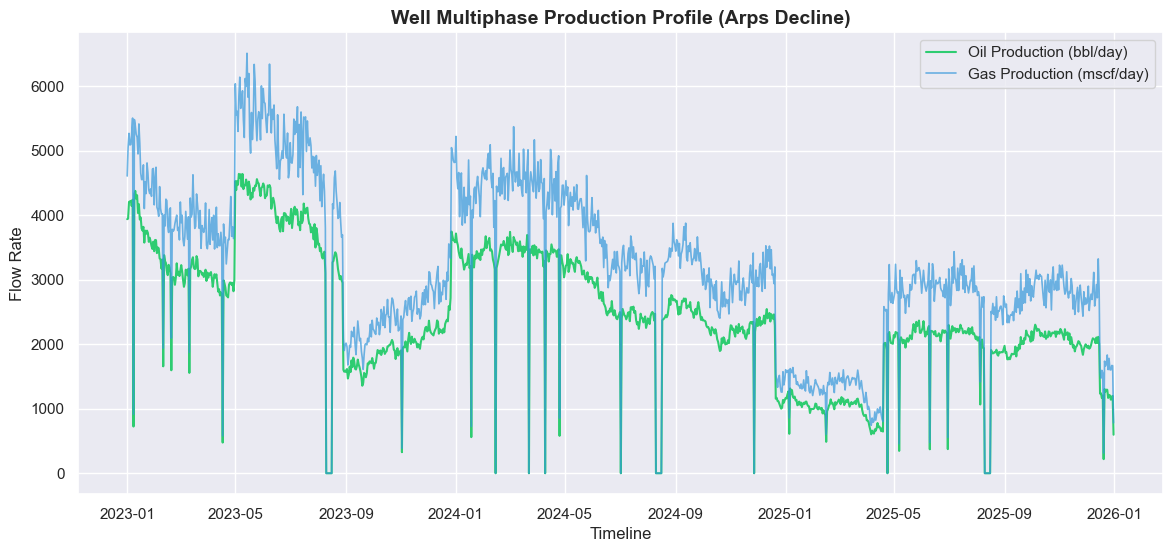

In [3]:
# Plot Production Volumes
plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["oil_volume_bbl"], label="Oil Production (bbl/day)", color="#2ecc71", lw=1.5)
plt.plot(df["date"], df["gas_volume_mscf"], label="Gas Production (mscf/day)", color="#3498db", lw=1.2, alpha=0.7)
plt.title("Well Multiphase Production Profile (Arps Decline)", fontsize=14, fontweight="bold")
plt.xlabel("Timeline")
plt.ylabel("Flow Rate")
plt.legend()
plt.show()

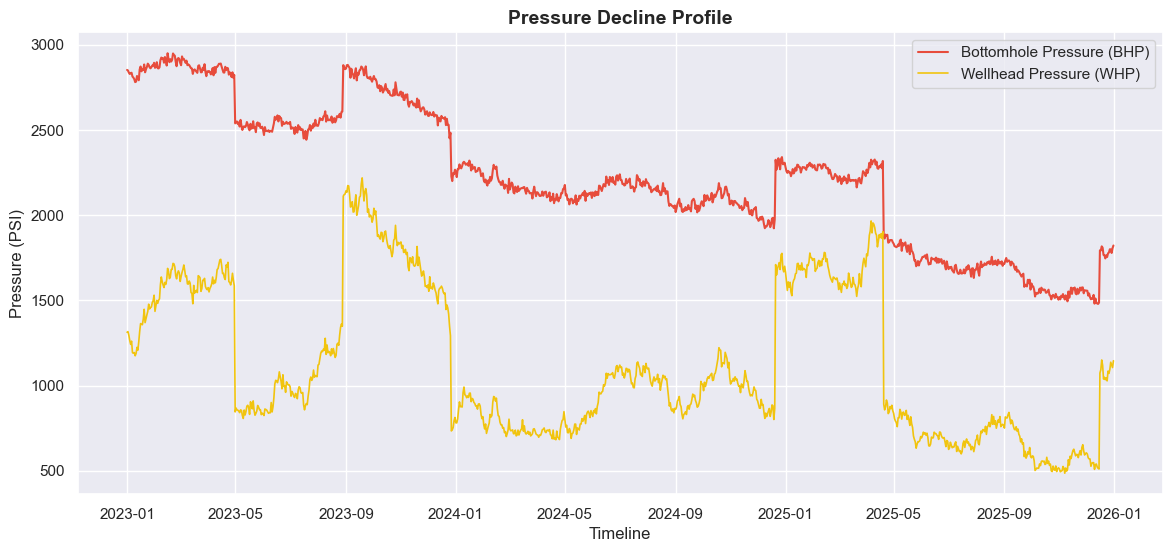

In [4]:
# Plot Bottomhole vs. Wellhead Pressures
plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["bottomhole_pressure_psi"], label="Bottomhole Pressure (BHP)", color="#e74c3c", lw=1.5)
plt.plot(df["date"], df["wellhead_pressure_psi"], label="Wellhead Pressure (WHP)", color="#f1c40f", lw=1.2)
plt.title("Pressure Decline Profile", fontsize=14, fontweight="bold")
plt.xlabel("Timeline")
plt.ylabel("Pressure (PSI)")
plt.legend()
plt.show()

## 3. Physical Feature Correlation Matrix

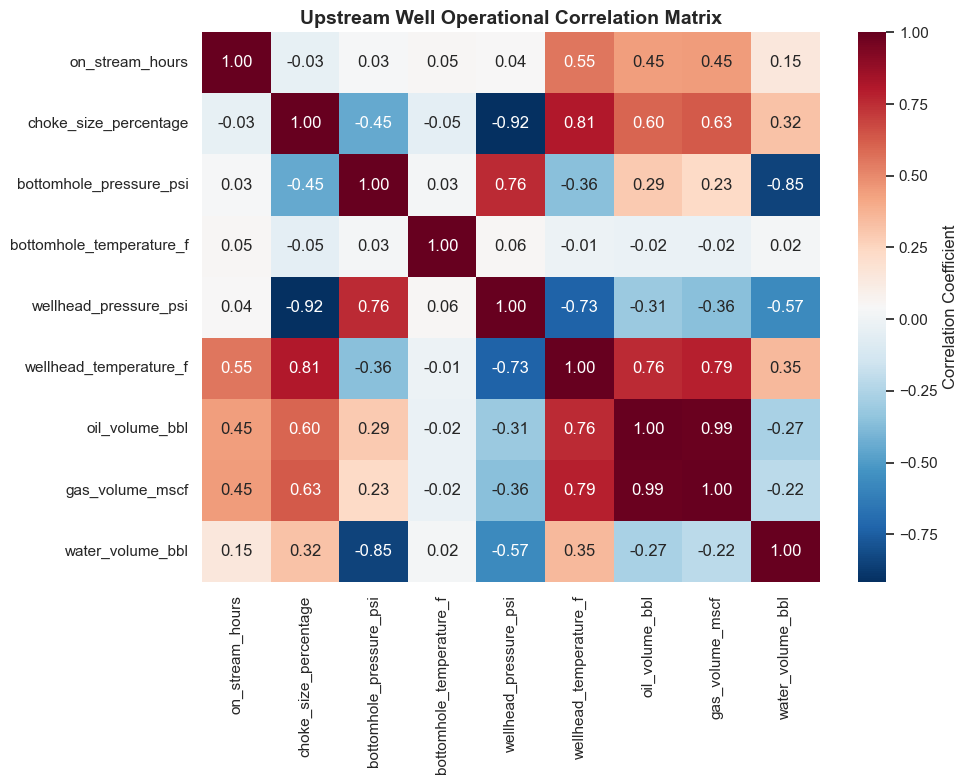

In [5]:
numeric_cols = [
    "on_stream_hours", "choke_size_percentage", "bottomhole_pressure_psi",
    "bottomhole_temperature_f", "wellhead_pressure_psi", "wellhead_temperature_f",
    "oil_volume_bbl", "gas_volume_mscf", "water_volume_bbl"
]

corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", cbar_kws={'label': 'Correlation Coefficient'})
plt.title("Upstream Well Operational Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Modeling: Virtual Flow Metering Regression
We fit a Random Forest Regressor to predict the daily oil flow rate (`oil_volume_bbl`) from sensor data when the well is active.

In [6]:
# Filter out shutdown days
df_active = df[df["on_stream_hours"] > 0].copy()

# Set features and target
features = [
    "on_stream_hours",
    "choke_size_percentage",
    "bottomhole_pressure_psi",
    "bottomhole_temperature_f",
    "wellhead_pressure_psi",
    "wellhead_temperature_f"
]
target = "oil_volume_bbl"

X = df_active[features]
y = df_active[target]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score:                   {r2:.4f}")
print(f"Mean Absolute Error (MAE):  {mae:.2f} bbl/day")
print(f"Root Mean Squared Error:    {rmse:.2f} bbl/day")

R² Score:                   0.9858
Mean Absolute Error (MAE):  61.78 bbl/day
Root Mean Squared Error:    103.71 bbl/day


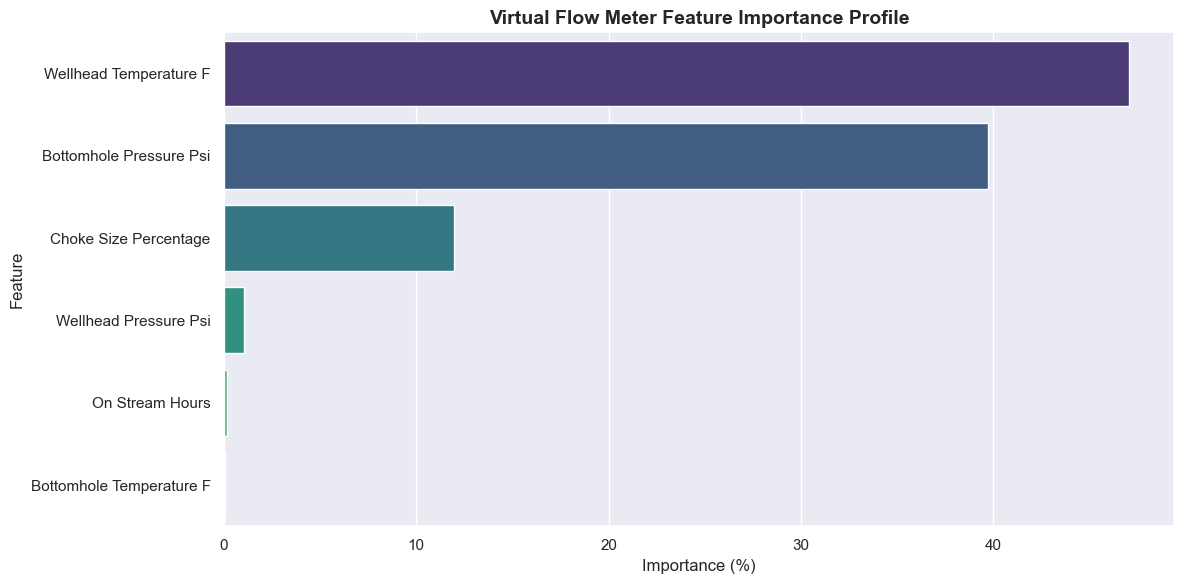

In [7]:
# Plot Feature Importances
importances = pd.DataFrame({
    'Feature': [f.replace("_", " ").title() for f in features],
    'Importance (%)': model.feature_importances_ * 100
}).sort_values(by='Importance (%)', ascending=False)

sns.barplot(data=importances, x='Importance (%)', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title("Virtual Flow Meter Feature Importance Profile", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()